In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
data = pd.read_csv("../data/guest_survey_data.csv")
data

,guest_id,age,family_size,first_visit,visit_frequency,visit_motivation,venue,education_program,spending,satisfaction,learning_score,likelihood_return,likelihood_recommend,participated_booth
0,10001,56,3,no,First visit,Entertainment,Garden,No,14.617588,3.0,4.0,3.0,3.0,1
1,10002,69,5,no,Quarterly,Entertainment,Curiosity Museum,Yes,11.742618,5.0,3.0,5.0,5.0,5
2,10003,46,4,yes,Quarterly,Exhibits,Farm,No,15.875554,4.0,3.0,4.0,4.0,2
3,10004,32,5,no,Quarterly,Education,Farm,Yes,5.942116,5.0,4.0,5.0,5.0,4
4,10005,60,5,no,First visit,Family Time,Garden,No,9.851911,5.0,2.0,5.0,5.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,11196,23,6,no,First visit,Nature,Dinosaurs,No,6.918145,4.0,5.0,4.0,4.0,2
1196,11197,43,5,no,First visit,Family Time,Curiosity Museum,No,4.196820,5.0,3.0,5.0,5.0,3
1197,11198,71,6,no,First visit,Family Time,Dinosaurs,Yes,0.000000,5.0,5.0,5.0,5.0,5
1198,11199,21,3,no,First visit,Education,Garden,No,14.380630,5.0,2.0,5.0,5.0,5


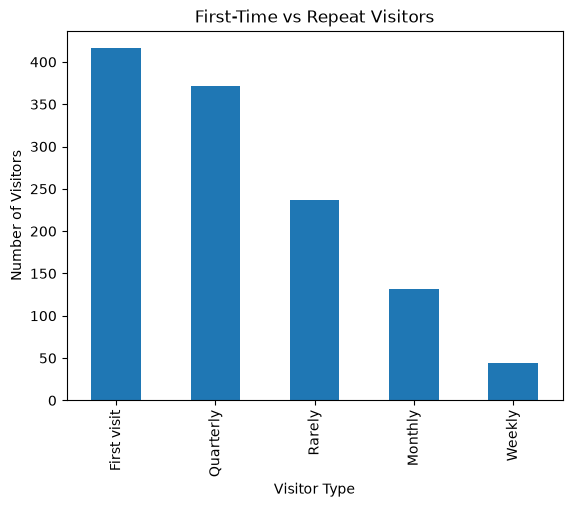

In [14]:
total_respondents = len(data)
average_age = data["age"].mean()
average_family_size = data["family_size"].mean()
visitor_counts = data["visit_frequency"].value_counts()

visitor_counts.plot(kind="bar")

plt.title("First-Time vs Repeat Visitors")
plt.xlabel("Visitor Type")
plt.ylabel("Number of Visitors")
plt.show()

### Q1. Who Are Our Guests?

The dashboard summarizes the size and basic demographic profile of survey respondents. 
It also compares first-time and repeat visitors to understand the balance between 
new guest acquisition and returning guests.

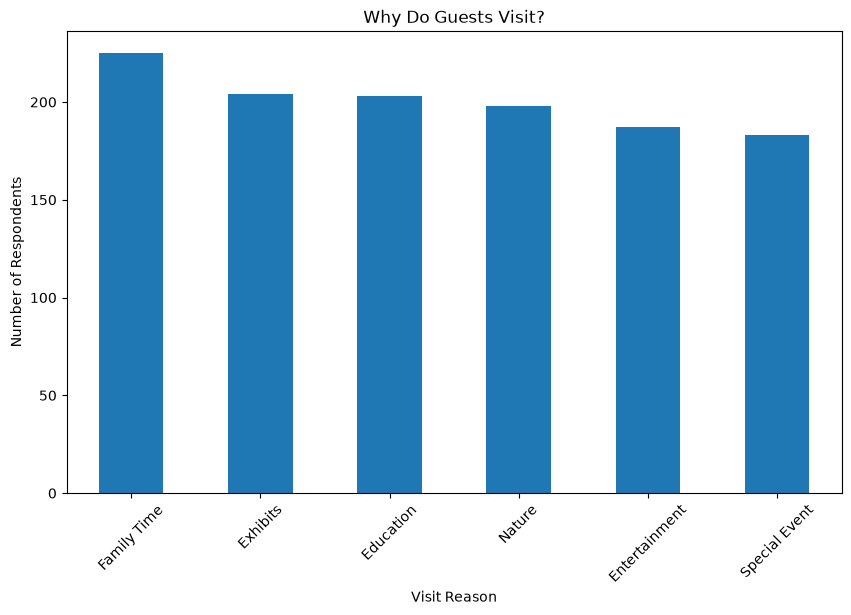

visit_motivation
Family Time      18.750000
Exhibits         17.000000
Education        16.916667
Nature           16.500000
Entertainment    15.583333
Special Event    15.250000
Name: proportion, dtype: float64

In [16]:
visit_reasons = data["visit_motivation"].value_counts()

plt.figure(figsize=(10, 6))
visit_reasons.plot(kind="bar")
plt.title("Why Do Guests Visit?")
plt.xlabel("Visit Reason")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)

plt.show()

visit_reason_percent = (
    data["visit_motivation"]
    .value_counts(normalize=True)
    .mul(100)
)

visit_reason_percent

### Q2. WHY DO THEY VISIT?
19% of respondents visited primarily for family time.

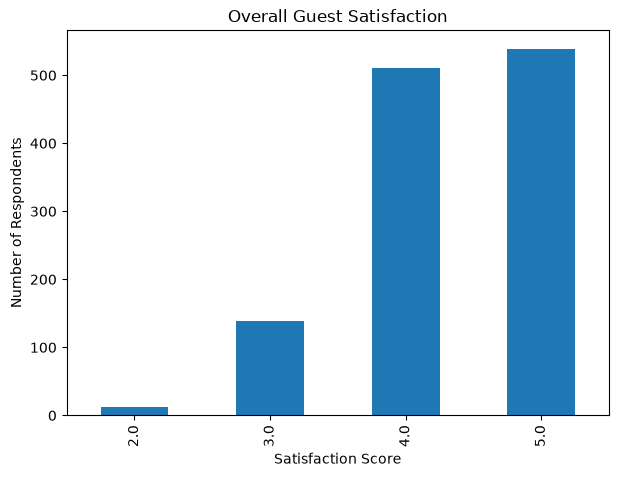

In [18]:
average_satisfaction = data["satisfaction"].mean()

plt.figure(figsize=(7, 5))
data["satisfaction"].value_counts().sort_index().plot(kind="bar")
plt.title("Overall Guest Satisfaction")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Respondents")

plt.show()

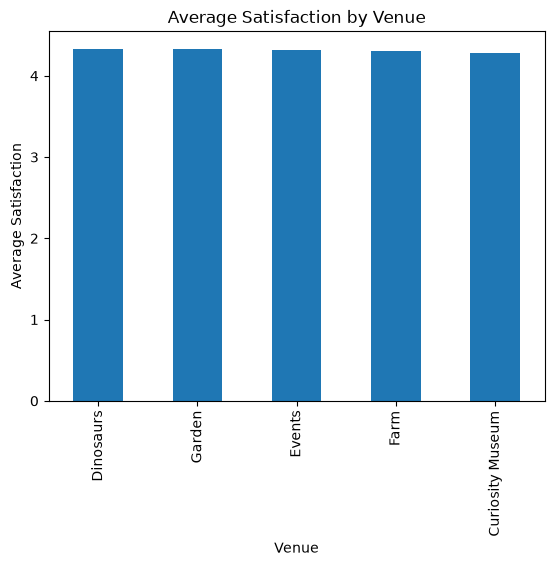

In [19]:
satisfaction_by_venue = (
    data.groupby("venue")["satisfaction"]
    .mean()
    .sort_values(ascending=False)
)

satisfaction_by_venue.plot(kind="bar")

plt.title("Average Satisfaction by Venue")
plt.xlabel("Venue")
plt.ylabel("Average Satisfaction")

plt.show()

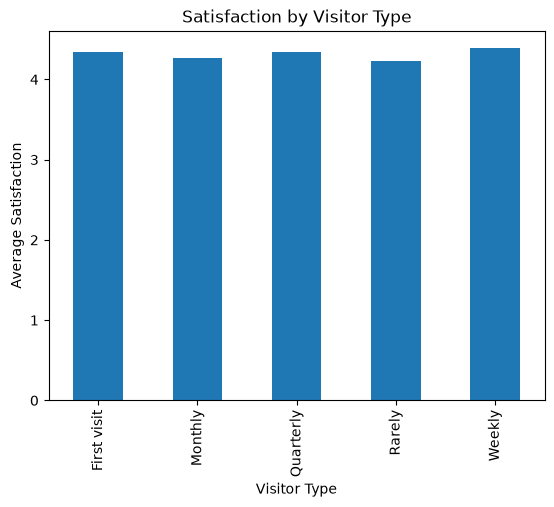

In [23]:
satisfaction_by_visitor = (
    data.groupby("visit_frequency")["satisfaction"]
    .mean()
)

satisfaction_by_visitor.plot(kind="bar")

plt.title("Satisfaction by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Average Satisfaction")

plt.show()

In [27]:
return_variables = data[
    [
        "satisfaction",
        "learning_score",
        "participated_booth",
        "likelihood_return"
    ]
]

return_correlation = return_variables.corr()
return_correlation["likelihood_return"].sort_values(
    ascending=False
)

likelihood_return     1.000000
satisfaction          0.794853
participated_booth    0.364522
learning_score       -0.006468
Name: likelihood_return, dtype: float64

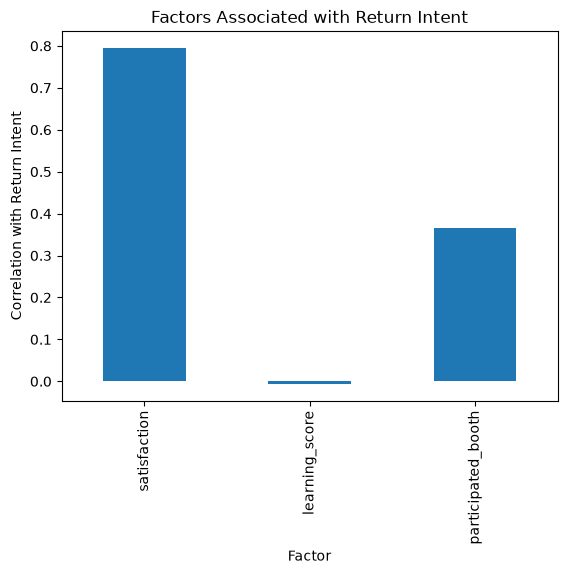

In [28]:
return_drivers = return_correlation[
    "likelihood_return"
].drop("likelihood_return")

return_drivers.plot(kind="bar")

plt.title("Factors Associated with Return Intent")
plt.xlabel("Factor")
plt.ylabel("Correlation with Return Intent")

plt.show()

### Q4 What Drives Return Visits?

Satisfaction, learning, and participated booth were examined in relation to 
likelihood of returning. Positive correlations indicate that higher 
values of the factor are associated with greater return intent, while 
negative correlations indicate an inverse relationship.

Correlation does not establish causation, so these results should be 
interpreted as associations rather than proof that one factor causes 
another.

In [29]:
participated_booth_corr = data[
    ["participated_booth", "likelihood_return"]
].corr().iloc[0, 1]

participated_booth_corr

np.float64(0.36452179154210873)

In [30]:
learning_return_corr = data[
    ["learning_score", "likelihood_return"]
].corr().iloc[0, 1]

learning_return_corr

np.float64(-0.006468069411095075)

In [32]:
program_return = (
    data.groupby("visit_motivation")["likelihood_return"]
    .mean()
)

program_return

visit_motivation
Education        4.384236
Entertainment    4.192513
Exhibits         4.269608
Family Time      4.288889
Nature           4.343434
Special Event    4.218579
Name: likelihood_return, dtype: float64